# Exploratory Data Analysis (EDA) Part 2: Feature & Integrity Analysis

## Goal
Perform deep analysis on the audio features and integrity of the dataset.

### Key Checks
1.  **Feature Analysis**: Extract and analyze MFCCs (Mel-Frequency Cepstral Coefficients).
2.  **Dimensionality Reduction**: Visualizing the features using t-SNE to see if classes form distinct clusters.
3.  **Integrity & Leakage**: Check for potential data leakage (augmented files) and source bias (ESC-50 vs US8K).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import os
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Settings
META_PATH = '../data/processed/master_metadata.csv'
AUDIO_DIR = '../data/processed/audio/'
plt.style.use('ggplot')

## 1. Feature Extraction (MFCCs)
We will extract Mean MFCCs for each file to use as features for visualization.

In [14]:
df = pd.read_csv(META_PATH)

def extract_features(file_path, n_mfcc=13):
    try:
        y, sr = librosa.load(file_path, sr=None)
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        # Take the mean across time (temporal averaging)
        mfccs_mean = np.mean(mfccs.T, axis=0)
        return mfccs_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Extract for all files
print("Extracting features...")
features = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    feats = extract_features(row['filepath'])
    features.append(feats)

X = np.array([f for f in features if f is not None])
# Drop rows where extraction failed (if any)
df = df.iloc[[i for i, f in enumerate(features) if f is not None]].reset_index(drop=True)

print(f"Feature matrix shape: {X.shape}")

Extracting features...


100%|██████████| 920/920 [00:05<00:00, 169.24it/s]

Feature matrix shape: (920, 13)


## 2. Feature Analysis (MFCC Profiles)
Let's look at the average MFCC profile for each class. If the lines are distinct, the classes are separable.

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_94423/2267634760.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=mfcc_long, x='MFCC_Coef', y='Value', hue='class', ci='sd')


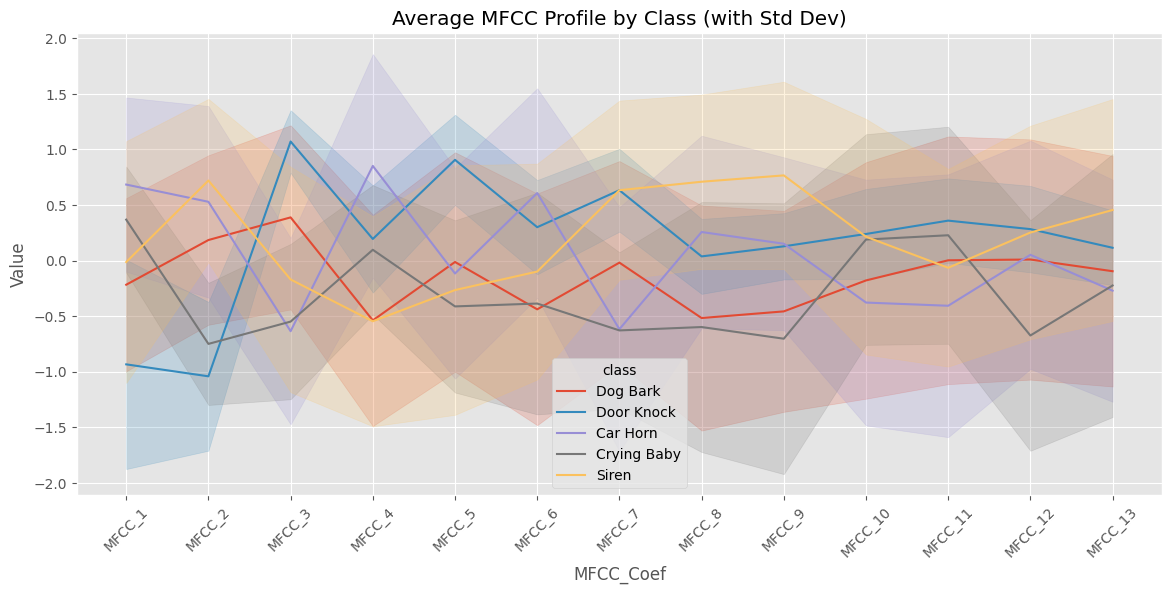

In [15]:
# Scale features for better visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a DataFrame for plotting
mfcc_df = pd.DataFrame(X_scaled, columns=[f'MFCC_{i+1}' for i in range(X_scaled.shape[1])])
mfcc_df['class'] = df['class']

# Melt for seaborn
mfcc_long = pd.melt(mfcc_df, id_vars='class', var_name='MFCC_Coef', value_name='Value')

plt.figure(figsize=(14, 6))
sns.lineplot(data=mfcc_long, x='MFCC_Coef', y='Value', hue='class', ci='sd')
plt.title('Average MFCC Profile by Class (with Std Dev)')
plt.xticks(rotation=45)
plt.show()

## 3. Dimensionality Reduction (t-SNE)
Projecting the 13-dimensional MFCCs into 2D to see clusters.

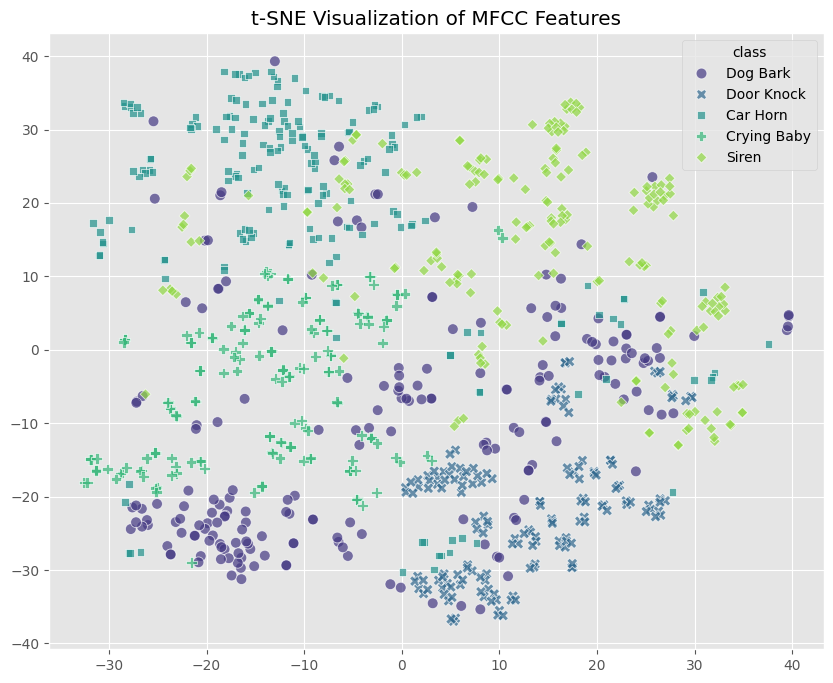

In [16]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=df['class'], 
    style=df['class'],
    palette='viridis',
    s=60,
    alpha=0.7
)
plt.title('t-SNE Visualization of MFCC Features')
plt.show()

### Interpretation
- **Distinct Clusters**: Good! The model will likely learn easily.
- **Overlapping Clusters**: The model might struggle (e.g., Siren vs Car Horn might overlap).

## 4. Integrity Analysis

### Leakage Check (Augmentation)
We need to ensure that when we split data into Train/Test later, we **do not** put an original file in Train and its augmented version in Test. This would be data leakage.

**Strategy**: We must group by `source_file` during splitting. Let's verify how many augmentations exist per source file.

In [17]:
# Count variations per source file
source_counts = df['source_file'].value_counts()

print("Variations per original file (Top 10):")
print(source_counts.head(10))

print(f"\nUnique Source Files: {len(source_counts)}")
print(f"Total Samples: {len(df)}")

# If we have ~200 samples per class:
# For US8K classes (no aug), unique sources should approx equal total samples.
# For ESC-50 classes (aug), unique sources should be much lower (e.g. 40).

Variations per original file (Top 10):
source_file
1-101336-A-30.wav    4
1-103995-A-30.wav    4
1-103999-A-30.wav    4
1-26188-A-30.wav     4
1-52290-A-30.wav     4
1-81001-A-30.wav     4
1-81001-B-30.wav     4
1-82817-A-30.wav     4
2-114254-A-30.wav    4
2-118624-A-30.wav    4
Name: count, dtype: int64

Unique Source Files: 680
Total Samples: 920


### Source Bias (Dataset Specific Noise)
Does the model just learn "This is ESC-50" vs "This is US8K"? 
Ideally, if we have the same class from both (e.g., Siren), they should overlap in t-SNE.

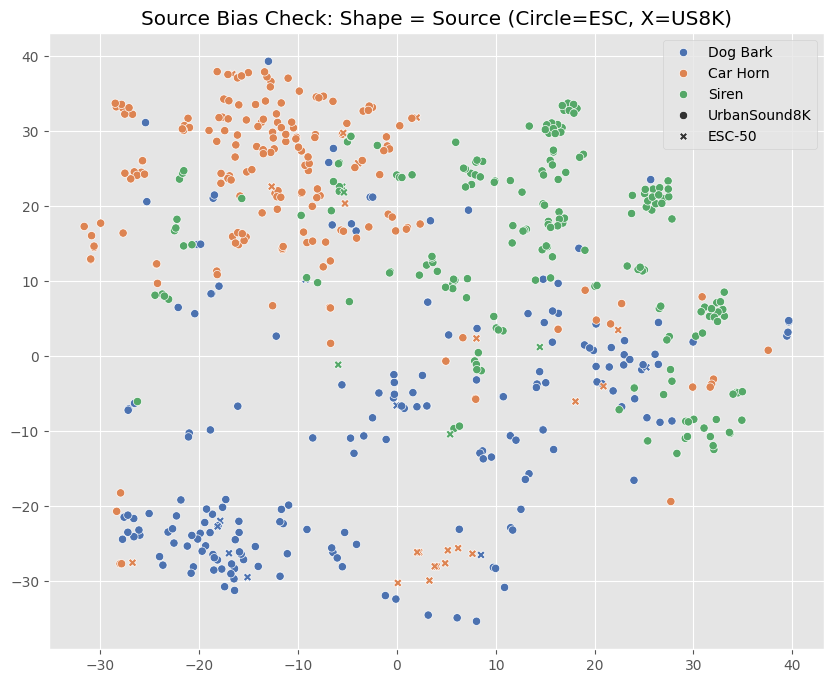

In [18]:
# Ensure 'source' column exists (Fix if missing metadata)
if 'source' not in df.columns:
    print("Reconstructing 'source' column from filenames...")
    def get_source(row):
        fname = row.get('source_file', '')
        # ESC-50 has letters (like 'A') in filename, US8K is all numbers/dashes
        if any(c.isalpha() for c in fname.replace('.wav', '')):
             return 'ESC-50'
        return 'UrbanSound8K'
        
    df['source'] = df.apply(get_source, axis=1)
    print("Source column reconstructed.")

# Check classes that exist in BOTH datasets (Siren, Car Horn, Dog Bark)
shared_classes = ['Siren', 'Car Horn', 'Dog Bark']
df_shared = df[df['class'].isin(shared_classes)].copy()

if not df_shared.empty and 'ESC-50' in df_shared['source'].unique() and 'UrbanSound8K' in df_shared['source'].unique():
    # Re-run t-SNE just for shared classes to see source separation
    # Note: We reuse X_tsne indices aligned with df indices
    shared_indices = df_shared.index
    X_shared = X_tsne[shared_indices]
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=X_shared[:, 0], 
        y=X_shared[:, 1], 
        hue=df_shared['class'].values, 
        style=df_shared['source'].values, # Shape by Source
        palette='deep'
    )
    plt.title('Source Bias Check: Shape = Source (Circle=ESC, X=US8K)')
    plt.show()
else:
    print("Not enough shared classes/sources to visualize source bias specifically.")